#Mt5 with Lora

In [1]:
import warnings
warnings.filterwarnings("ignore")
!pip install --upgrade torchao peft transformers
from transformers import MT5ForConditionalGeneration, T5Tokenizer
model_path = '/content/drive/MyDrive/mt5_small_lora2(epo5)'  # Update if your path is different
model = MT5ForConditionalGeneration.from_pretrained(model_path)
tokenizer = T5Tokenizer.from_pretrained(model_path)

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loading weights:   0%|          | 0/96 [00:00<?, ?it/s]

In [2]:
def generate_summary(text):
    inputs = tokenizer("summarize: " + text, return_tensors="pt", truncation=True, max_length=512).to(model.device)

    summary_ids = model.generate(
        inputs.input_ids,
        max_length=150,  # Limit summary length
        do_sample=True,  # Enable sampling for more variety
        top_k=50,  # Consider top 50 predictions at each step
        top_p=0.95,  # Use nucleus sampling
        repetition_penalty=2.0,  # Penalize repetition
        no_repeat_ngram_size=3,  # Prevent repeating n-grams
        early_stopping=True
    )

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

In [3]:
text_to_summarize = "नेपाल एक सुन्दर देश हो जसको प्राकृतिक सौन्दर्य, संस्कृतिक विविधता र ऐतिहासिक महत्व रहेको छ। यो देशमा हिमाल, पहाड, तराई गरी तीनवटा भौगोलिक क्षेत्रहरू छन्। संसारकै अग्लो हिमाल सगरमाथा नेपालमा अवस्थित छ, जसले पर्यटकहरूलाई आकर्षित गर्छ। यसबाहेक, नेपाल विभिन्न धार्मिक तथा सांस्कृतिक स्थलहरूका कारण पनि प्रसिद्ध छ। पशुपतिनाथ मन्दिर, लुम्बिनी (गौतम बुद्ध जन्मस्थल), स्वयम्भूनाथ, र भक्तपुर दरबार क्षेत्र जस्ता स्थानहरू धार्मिक तथा ऐतिहासिक रूपमा महत्वपूर्ण छन्। नेपाल बहुसांस्कृतिक र बहुभाषिक राष्ट्र हो, जहाँ विभिन्न जाति, भाषा र धर्मका मानिसहरू मिलेर बसेका छन्। यहाँका मुख्य चाडपर्वहरू दशैँ, तिहार, होली, ल्होसार, छठ, र तीज हुन्। कृषि नेपालका धेरैजसो जनताको मुख्य पेशा हो, यद्यपि पर्यटन, उद्योग र व्यापारले पनि अर्थतन्त्रमा योगदान पुऱ्याएका छन्। नेपाल सरकार लोकतान्त्रिक गणतन्त्र प्रणालीमा आधारित छ, जसमा संघीय, प्रदेश, र स्थानीय सरकारको संरचना रहेको छ।"
summary = generate_summary(text_to_summarize)
print(summary)

[transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


<extra_id_0> नेपाल एक सुन्दर देश हो जसको प्राकृतिक सौंदर्य, संस्कृतिक विविधता तथा ऐतिहासिक महत्व देखिएको छ। यो क्षेत्रमा हिमाल केसगमका भौगोलिक विविधा र वैटोमिक आवृत्तिहरूले जातिको मुख्य पेशाहरू हुन्।


In [4]:
!pip install rouge # Install the 'rouge' package
!pip install rouge_score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=488cf185e216538e6fa3249f8fd47c848baba5b9245de54ca17f5745436c5753
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [5]:
from rouge_score import rouge_scorer
from rouge import Rouge  # Now this import should work

# Reference (gold) summary
reference_summary = "नेपाल प्राकृतिक सौन्दर्य, संस्कृतिक विविधता र ऐतिहासिक महत्त्वले भरिएको देश हो। यहाँ हिमाल, पहाड, तराई गरी तीन भौगोलिक क्षेत्रहरू छन्। सगरमाथा, पशुपतिनाथ, लुम्बिनी, र भक्तपुर दरबार क्षेत्र जस्ता स्थलहरूले पर्यटकलाई आकर्षित गर्छन्। नेपाल बहुसांस्कृतिक राष्ट्र हो, जहाँ विभिन्न भाषा, धर्म, र जातिका मानिसहरू बस्छन्। प्रमुख चाडपर्वहरू दशैँ, तिहार, र तीज हुन्। कृषि मुख्य पेशा भए पनि पर्यटन, उद्योग, र व्यापारले अर्थतन्त्रमा योगदान गर्छ। नेपालको शासन व्यवस्था लोकतान्त्रिक गणतन्त्र हो।"

# Predicted summary
predicted_summary =summary
import unicodedata
reference_summary = unicodedata.normalize("NFKC", reference_summary)
predicted_summary = unicodedata.normalize("NFKC", predicted_summary)

rouge = Rouge()
scores = rouge.get_scores(predicted_summary, reference_summary)
print(scores)

[{'rouge-1': {'r': 0.15873015873015872, 'p': 0.3448275862068966, 'f': 0.21739130003071838}, 'rouge-2': {'r': 0.014705882352941176, 'p': 0.03571428571428571, 'f': 0.020833329201389705}, 'rouge-l': {'r': 0.12698412698412698, 'p': 0.27586206896551724, 'f': 0.1739130391611532}}]


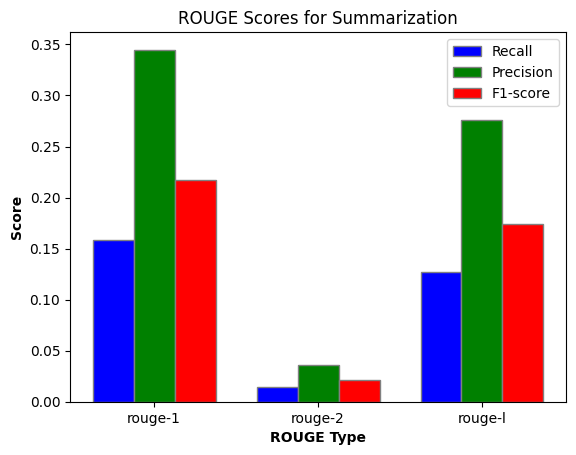

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Your ROUGE scores
scores = scores


# Extract ROUGE scores for plotting
rouge_types = ['rouge-1', 'rouge-2', 'rouge-l']
recall_scores = [scores[0][rouge_type]['r'] for rouge_type in rouge_types]
precision_scores = [scores[0][rouge_type]['p'] for rouge_type in rouge_types]
f1_scores = [scores[0][rouge_type]['f'] for rouge_type in rouge_types]

# Set up the bar plot
barWidth = 0.25
r1 = np.arange(len(rouge_types))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

# Create the bars
plt.bar(r1, recall_scores, color='b', width=barWidth, edgecolor='grey', label='Recall')
plt.bar(r2, precision_scores, color='g', width=barWidth, edgecolor='grey', label='Precision')
plt.bar(r3, f1_scores, color='r', width=barWidth, edgecolor='grey', label='F1-score')

# Add labels and title
plt.xlabel('ROUGE Type', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(rouge_types))], rouge_types)
plt.title('ROUGE Scores for Summarization')

# Add legend
plt.legend()

# Show the plot
plt.show()

#Mt5 Full Fined Tuned

In [12]:
from transformers import MT5ForConditionalGeneration, T5Tokenizer
model_path = '/content/drive/MyDrive/mt5_nepali_summarizer'  # Update if your path is different
model = MT5ForConditionalGeneration.from_pretrained(model_path)
tokenizer = T5Tokenizer.from_pretrained(model_path)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


In [13]:
def generate_summary(text):
    inputs = tokenizer("summarize: " + text, return_tensors="pt", truncation=True, max_length=512).to(model.device)

    summary_ids = model.generate(
        inputs.input_ids,
        max_length=150,  # Limit summary length
        do_sample=True,  # Enable sampling for more variety
        top_k=50,  # Consider top 50 predictions at each step
        top_p=0.95,  # Use nucleus sampling
        repetition_penalty=2.0,  # Penalize repetition
        no_repeat_ngram_size=3,  # Prevent repeating n-grams
        early_stopping=True
    )

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

In [14]:
text_to_summarize = "नेपाल एक सुन्दर देश हो जसको प्राकृतिक सौन्दर्य, संस्कृतिक विविधता र ऐतिहासिक महत्व रहेको छ। यो देशमा हिमाल, पहाड, तराई गरी तीनवटा भौगोलिक क्षेत्रहरू छन्। संसारकै अग्लो हिमाल सगरमाथा नेपालमा अवस्थित छ, जसले पर्यटकहरूलाई आकर्षित गर्छ। यसबाहेक, नेपाल विभिन्न धार्मिक तथा सांस्कृतिक स्थलहरूका कारण पनि प्रसिद्ध छ। पशुपतिनाथ मन्दिर, लुम्बिनी (गौतम बुद्ध जन्मस्थल), स्वयम्भूनाथ, र भक्तपुर दरबार क्षेत्र जस्ता स्थानहरू धार्मिक तथा ऐतिहासिक रूपमा महत्वपूर्ण छन्। नेपाल बहुसांस्कृतिक र बहुभाषिक राष्ट्र हो, जहाँ विभिन्न जाति, भाषा र धर्मका मानिसहरू मिलेर बसेका छन्। यहाँका मुख्य चाडपर्वहरू दशैँ, तिहार, होली, ल्होसार, छठ, र तीज हुन्। कृषि नेपालका धेरैजसो जनताको मुख्य पेशा हो, यद्यपि पर्यटन, उद्योग र व्यापारले पनि अर्थतन्त्रमा योगदान पुऱ्याएका छन्। नेपाल सरकार लोकतान्त्रिक गणतन्त्र प्रणालीमा आधारित छ, जसमा संघीय, प्रदेश, र स्थानीय सरकारको संरचना रहेको छ।"
summary = generate_summary(text_to_summarize)
print(summary)

न्दन नेपाल एक सुन्दर देश हो जसको प्राकृतिक सौन्दर्य, संस्कृतिक विविधता तथा ऐतिहासिक महत्व छ। यो संसारमा हिमाल, पहाड, तराईसहित चारवटा भौगोलिक क्षेत्रहरूका कारण आकर्षित गरेका छन्।


In [15]:
from rouge_score import rouge_scorer
from rouge import Rouge  # Now this import should work

# Reference (gold) summary
reference_summary = "नेपाल प्राकृतिक सौन्दर्य, संस्कृतिक विविधता र ऐतिहासिक महत्त्वले भरिएको देश हो। यहाँ हिमाल, पहाड, तराई गरी तीन भौगोलिक क्षेत्रहरू छन्। सगरमाथा, पशुपतिनाथ, लुम्बिनी, र भक्तपुर दरबार क्षेत्र जस्ता स्थलहरूले पर्यटकलाई आकर्षित गर्छन्। नेपाल बहुसांस्कृतिक राष्ट्र हो, जहाँ विभिन्न भाषा, धर्म, र जातिका मानिसहरू बस्छन्। प्रमुख चाडपर्वहरू दशैँ, तिहार, र तीज हुन्। कृषि मुख्य पेशा भए पनि पर्यटन, उद्योग, र व्यापारले अर्थतन्त्रमा योगदान गर्छ। नेपालको शासन व्यवस्था लोकतान्त्रिक गणतन्त्र हो।"

# Predicted summary
predicted_summary =summary
import unicodedata
reference_summary = unicodedata.normalize("NFKC", reference_summary)
predicted_summary = unicodedata.normalize("NFKC", predicted_summary)

rouge = Rouge()
scores = rouge.get_scores(predicted_summary, reference_summary)
print(scores)


[{'rouge-1': {'r': 0.19047619047619047, 'p': 0.4444444444444444, 'f': 0.2666666624666667}, 'rouge-2': {'r': 0.058823529411764705, 'p': 0.15384615384615385, 'f': 0.08510637897691282}, 'rouge-l': {'r': 0.15873015873015872, 'p': 0.37037037037037035, 'f': 0.22222221802222225}}]


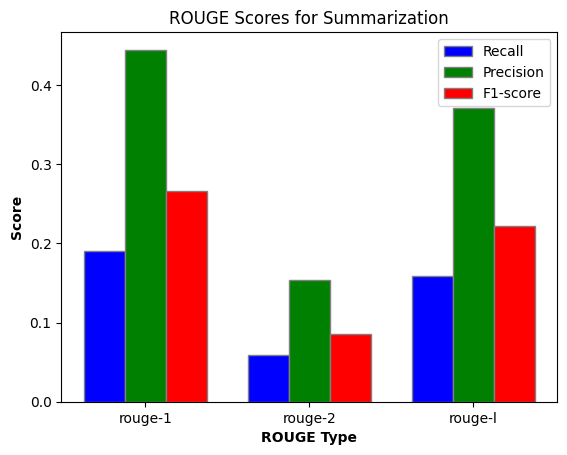

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Your ROUGE scores
scores = scores


# Extract ROUGE scores for plotting
rouge_types = ['rouge-1', 'rouge-2', 'rouge-l']
recall_scores = [scores[0][rouge_type]['r'] for rouge_type in rouge_types]
precision_scores = [scores[0][rouge_type]['p'] for rouge_type in rouge_types]
f1_scores = [scores[0][rouge_type]['f'] for rouge_type in rouge_types]

# Set up the bar plot
barWidth = 0.25
r1 = np.arange(len(rouge_types))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

# Create the bars
plt.bar(r1, recall_scores, color='b', width=barWidth, edgecolor='grey', label='Recall')
plt.bar(r2, precision_scores, color='g', width=barWidth, edgecolor='grey', label='Precision')
plt.bar(r3, f1_scores, color='r', width=barWidth, edgecolor='grey', label='F1-score')

# Add labels and title
plt.xlabel('ROUGE Type', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(rouge_types))], rouge_types)
plt.title('ROUGE Scores for Summarization')

# Add legend
plt.legend()

# Show the plot
plt.show()